In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve()
for candidate in [project_root, project_root.parent]:
    if (candidate / "src").exists():
        sys.path.insert(0, str(candidate))
        break

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import AutoTokenizer

from src.config import (
    DATASET_NAME,
    MODEL_NAME,
)

In [3]:
dataset = load_dataset(DATASET_NAME)

README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

c:\Users\Yuv\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Yuv\.cache\huggingface\hub\datasets--tgrex6--mimic-cxr-reports-summarization. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


train.json:   0%|          | 0.00/65.4M [00:00<?, ?B/s]

dev.json:   0%|          | 0.00/1.43M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/91544 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [4]:
train_df = dataset["train"].to_pandas()

In [5]:
train_df.head()

,subject_id,findings,study_id,background,impression
0,11148901,The heart is normal in size. The mediastinal a...,58832226,CHEST RADIOGRAPHS HISTORY: Chest pain. COMPARI...,No evidence of acute disease.
1,11648038,Frontal and lateral views of the chest were ob...,52876267,INDICATION: ___-year-old female with dyspnea. ...,Slight pulmonary vascular congestion without p...
2,11179382,The cardiac silhouette and pulmonary vasculatu...,50334688,EXAMINATION: CHEST (PA AND LAT) INDICATION: Hi...,No definite mass identified. Bibasilar opaciti...
3,11759245,ET tube terminates 29 mm above the carina. Tra...,56898500,INDICATION: ___ year old woman with schizophre...,Increased bibasilar opacities could be due to ...
4,11759245,Right PICC ends in the lower SVC. NG tube term...,58825745,EXAMINATION: Chest radiograph INDICATION: ___-...,"Probable, new right lower lobe pneumonia."


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 91544 entries, 0 to 91543
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   subject_id  91544 non-null  str  
 1   findings    91544 non-null  str  
 2   study_id    91544 non-null  str  
 3   background  91544 non-null  str  
 4   impression  91544 non-null  str  
dtypes: str(5)
memory usage: 58.2 MB


In [7]:
train_df.isnull().sum()

subject_id    0
findings      0
study_id      0
background    0
impression    0
dtype: int64

In [9]:
train_df["study_id"].duplicated().sum()

np.int64(0)

In [10]:
train_df["findings"].duplicated().sum()

np.int64(7987)

In [11]:
train_df["impression"].duplicated().sum()

np.int64(33934)

In [16]:
train_df["findings_length"] = train_df["findings"].str.len()

train_df["impression_length"] = train_df["impression"].str.len()

In [18]:
train_df[
    [
        "findings_length",
        "impression_length"
    ]
].describe()

,findings_length,impression_length
count,91544.000000,91544.000000
mean,337.048130,99.187757
std,147.152963,81.920534
min,93.000000,16.000000
25%,232.000000,35.000000
50%,310.000000,71.000000
75%,411.000000,135.000000
max,1828.000000,1062.000000


<Axes: xlabel='findings_length', ylabel='Count'>

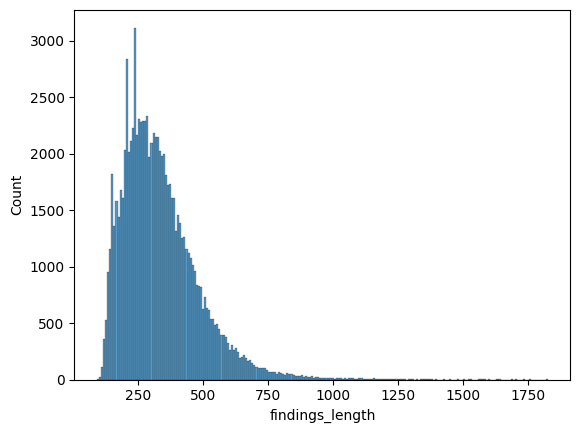

In [19]:
sns.histplot(train_df["findings_length"])

<Axes: xlabel='impression_length', ylabel='Count'>

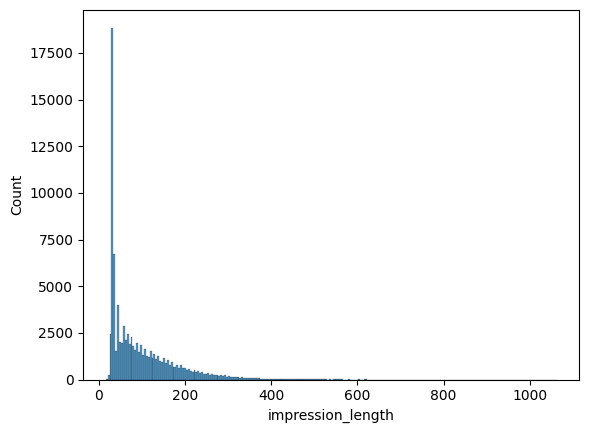

In [20]:
sns.histplot(train_df["impression_length"])

In [23]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [24]:
#Findings tokenization

train_df["input_tokens"] = train_df["findings"].apply(

    lambda x: len(
        tokenizer.encode(
            x,
            truncation=False
        )
    )
)

In [26]:
#Impression tokenization

train_df["target_tokens"] = train_df["impression"].apply(

    lambda x: len(
        tokenizer.encode(
            x,
            truncation=False
        )
    )
)

<Axes: xlabel='input_tokens', ylabel='Count'>

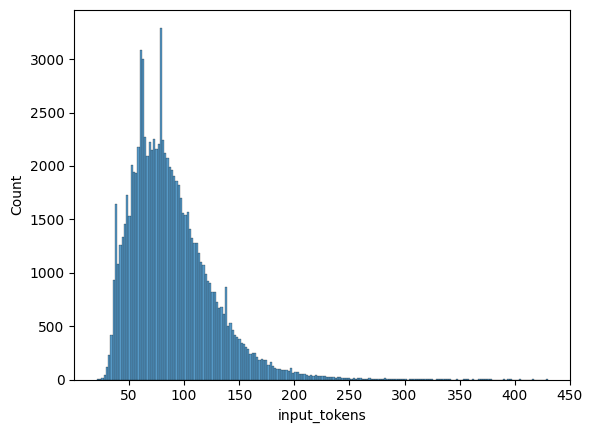

In [27]:
sns.histplot(train_df["input_tokens"])

<Axes: xlabel='target_tokens', ylabel='Count'>

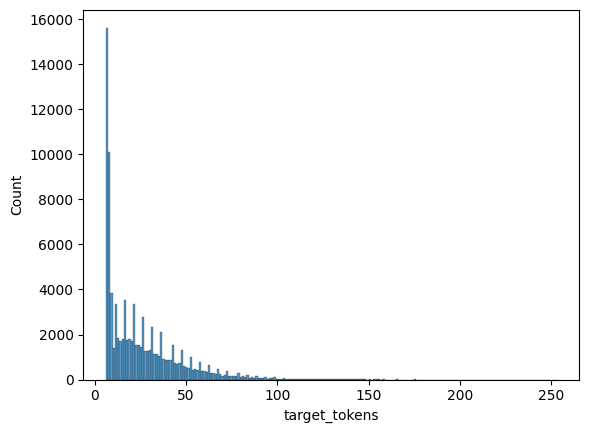

In [28]:
sns.histplot(train_df["target_tokens"])

In [29]:
train_df[["input_tokens", "target_tokens"]].describe()

,input_tokens,target_tokens
count,91544.000000,91544.000000
mean,88.083020,25.554684
std,36.684368,21.469649
min,21.000000,6.000000
25%,61.000000,8.000000
50%,82.000000,19.000000
75%,107.000000,36.000000
max,430.000000,253.000000


# EDA Observations

## Dataset Overview

- The training dataset contains 91,544 radiology reports.
- Each study is unique with no duplicate `study_id` values.

## Missing Values

- No missing values were observed in the `findings` or `impression` columns.
- The `background` column contains missing values and will not be used during Week 2.

## Duplicate Analysis

- Duplicate `findings` and `impression` values are expected because radiology reports often follow standardized templates.
- No fully duplicated records were found.

## Token Length Analysis

- The average input length is approximately 88 tokens.
- The average target length is approximately 26 tokens.
- The longest input contains 430 tokens.
- Therefore, `MAX_INPUT_LENGTH = 512` is sufficient and no input reports will be truncated.
- Target lengths will be evaluated before deciding whether `MAX_TARGET_LENGTH = 128` is appropriate.

## Conclusion

The dataset is clean and suitable for training a transformer-based summarization model with minimal preprocessing.